In [9]:
import numpy as np
from qutip import\
    tensor, sigmax, sigmay, sigmaz, sigmam, sigmap, qeye, qzero, create, destroy, basis
from qutip.qip.operations import rx, ry, rz
from scipy.linalg import block_diag
import qutip as qt

import matplotlib.pyplot as plt

The matrix representation of the system in the lab frame is with respect to basis:
$$\{\ket{R,\uparrow}, \ket{L,\uparrow}, \ket{R,\uparrow}, \ket{L,\downarrow}\}$$

The Hamiltonian in one DQD:
$$H_0 = t_c\tau
_x + \frac{\epsilon}{2} \tau_z + \frac{B_z}{2}\sigma_z + \frac{\Delta B_x}{2} \sigma_x \tau_z$$

$\epsilon$: asymmetry of DQD ($\epsilon > 0$ then right potential well is higher than the left)\
$t_c$: tunneling coupling \
$B_z$: Zeeman splitting (up-spin has higher energy for $B_z > 0$) \
$B_x$: transverse magnetic field gradient

For this work, we use symmetric DQD, i.e., $\epsilon = 0$


In [10]:
sx = tensor(tensor(sigmax(), qeye(2)))
sy = tensor(tensor(sigmay(), qeye(2)))
sz = tensor(tensor(sigmaz(), qeye(2)))
sm = tensor(tensor(sigmam(), qeye(2)))
tx = tensor(tensor(qeye(2), sigmax()))
ty = tensor(tensor(qeye(2), sigmay()))
tz = tensor(tensor(qeye(2), sigmaz()))

sx1 = tensor(tensor(sigmax(), qeye(2)), qeye([2,2]))
sy1 = tensor(tensor(sigmay(), qeye(2)), qeye([2,2]))
sz1 = tensor(tensor(sigmaz(), qeye(2)), qeye([2,2]))
sm1 = tensor(tensor(sigmam(), qeye(2)), qeye([2,2]))
tx1 = tensor(tensor(qeye(2), sigmax()), qeye([2,2]))
ty1 = tensor(tensor(qeye(2), sigmay()), qeye([2,2]))
tz1 = tensor(tensor(qeye(2), sigmaz()), qeye([2,2]))

sx2 = tensor(qeye([2,2]), tensor(sigmax(), qeye(2)))
sy2 = tensor(qeye([2,2]), tensor(sigmay(), qeye(2)))
sz2 = tensor(qeye([2,2]), tensor(sigmaz(), qeye(2)))
sm2 = tensor(qeye([2,2]), tensor(sigmam(), qeye(2)))
tx2 = tensor(qeye([2,2]), tensor(qeye(2), sigmax()))
ty2 = tensor(qeye([2,2]), tensor(qeye(2), sigmay()))
tz2 = tensor(qeye([2,2]), tensor(qeye(2), sigmaz()))

## Parameters

In [ ]:
HBAR_J_S = 1.054571817e-34
ELEMENTARY_CHARGE_C = 1.602176634e-19
MICROELECTRONVOLT_TO_JOULE = 1e-6 * ELEMENTARY_CHARGE_C
MICROSECOND_TO_SECOND = 1e-6
RAD_PER_US_PER_MICROELECTRONVOLT = MICROELECTRONVOLT_TO_JOULE * MICROSECOND_TO_SECOND / HBAR_J_S
tc = 80
Bz = 24 # μeV
bx = 20


# get phi_p, phi_m and phi_bar
phi_p = np.arctan2(bx, 2*tc + Bz)
if phi_p < 0: phi_p += np.pi

phi_m = np.arctan2(bx, 2*tc - Bz)
if phi_m < 0: phi_m += np.pi

phi_bar = 0.5 * (phi_p + phi_m)
print(phi_p * 180/np.pi)
print(phi_m * 180/np.pi)
print(phi_bar * 180/np.pi) # in degree

e2 = 1/2 * np.sqrt((2*tc-Bz)**2 + bx**2)
e3 = 1/2 * np.sqrt((2*tc+Bz)**2 + bx**2)

Esigma = e3 - e2
Etau = e3 + e2

print(Esigma, Etau)

6.203447901691836
8.36588612403259
7.284667012862213
23.81052130031587 161.27324351983253


In [12]:
wc = 2 * np.pi * 5.5e3 # MHz
gc = 2 * np.pi * 50 # MHz

d_sigma = Esigma * RAD_PER_US_PER_MICROELECTRONVOLT - wc
d_tau = Etau * RAD_PER_US_PER_MICROELECTRONVOLT - wc
g_sigma = gc * np.sin(phi_bar)
g_tau = gc * np.cos(phi_bar)

# verify dispersive regime
print(g_sigma, d_sigma)
print(g_tau, d_tau)
print(np.tan(phi_bar), d_sigma/d_tau)

39.83513160784701 1617.0307419006058
311.6235008799547 210459.66992294625
0.1278309610647514 0.007683328318877603


## Diagonalisation Confirmation

In [13]:
H0 = tc * tx + Bz/2 * sz + bx/2 * sx * tz

display(H0)
Rty = lambda theta : tensor(qeye(2), ry(theta))
H0_ob = Rty(-np.pi/2) * H0 * Rty(-np.pi/2).dag()

def direct_sum(*ops):
    from scipy.linalg import block_diag
    return qt.Qobj(block_diag(*[op.full() for op in ops]))

# Rphim = (- 0.5j *  qt.Qobj(direct_sum(qzero(1), sigmay(), qzero(1)) * (-phi_m), dims=[[2,2],[2,2]])).expm()
# Rphip = (- 0.5j *  qt.Qobj([[0, 0, 0, -1j], [0, 0, 0, 0], [0, 0, 0, 0], [1j, 0, 0, 0]], dims=[[2,2],[2,2]]) * phi_p).expm()
Rsxty = (- 0.5j *  sx*ty * (phi_bar)).expm()
Rsytx = (- 0.5j *  sy*tx * 0.5*(phi_p - phi_m)).expm()

# U_flop = Rphim * Rphip
U_flop = Rsytx * Rsxty
display((U_flop * H0_ob * U_flop.dag()).tidyup(atol=1e-12))


display((U_flop * Rty(-np.pi/2) * tz * Rty(-np.pi/2).dag() * U_flop.dag()).tidyup(atol = 1e-10 ))
display(-np.cos(phi_bar) * tx + np.sin(phi_bar) * sx * tz)


Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 12.  80.  10.   0.]
 [ 80.  12.   0. -10.]
 [ 10.   0. -12.  80.]
 [  0. -10.  80. -12.]]

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 92.54188241   0.           0.           0.        ]
 [  0.         -68.73136111   0.           0.        ]
 [  0.           0.          68.73136111   0.        ]
 [  0.           0.           0.         -92.54188241]]

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.         -0.99192841  0.12679916  0.        ]
 [-0.99192841  0.          0.         -0.12679916]
 [ 0.12679916  0.          0.         -0.99192841]
 [ 0.         -0.12679916 -0.99192841  0.        ]]

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.         -0.99192841  0.12679916  0.        ]
 [-0.99192841  0.          0.         -0.12679916]
 [ 0.12679916  0.          0.         -0.99192841]
 [ 0.         -0.12679916 -0.99192841  0.        ]]

In [14]:
H01 = tensor(qeye(10), tc * tx1 + Bz/2 *  sz1 + bx/2 *  sx1 *  tz1) * RAD_PER_US_PER_MICROELECTRONVOLT
H02 = tensor(qeye(10), tc * tx2 + Bz/2 *  sz2 + bx/2 *  sx2 *  tz2) * RAD_PER_US_PER_MICROELECTRONVOLT

a = tensor(destroy(10), qeye([2,2,2,2]))
# display((tc * tx1 + Bz/2 *  sz1 + bx/2 *  sx1 *  tz1) * RAD_PER_US_PER_MICROELECTRONVOLT)

H0photon = wc * a.dag() * a
V1 = gc * tensor(qeye(10), tz1) * (a + a.dag())
V2 = gc * tensor(qeye(10), tz2) * (a + a.dag())

## Simulation in Lab Frame

$\ket{\psi^{(1)}_0} = \ket{R, \uparrow}$ \
$\ket{\psi^{(2)}_0} = \ket{R, \downarrow}$

$\ket{\psi^{\rm DQD}_0} = \ket{\psi^{(1)}_0} \bigotimes \ket{\psi^{(2)}_0}$ \
$\ket{\psi^{\gamma}_0} = \ket{vac}$

$\ket{\psi_0} = \ket{\psi^{\gamma}_0} \bigotimes \ket{\psi^{\rm DQD}_0}$

In [15]:
tg = (np.pi/2 if d_sigma < 0 else 3 * np.pi/2) * np.abs(d_sigma) / (g_sigma)**2
print(d_sigma, tg)

def pulse1(t):
    return np.heaviside(t, 1) - np.heaviside(t-tg, 1)

H = [[H01 + H02 + V1 + V2 + H0photon, 1],]

U_flop_full = tensor(qeye(10), U_flop, U_flop)
U_ob_full = tensor(qeye(10),  Rty(-np.pi/2), Rty(-np.pi/2))

psi0 = tensor(basis(10,0), tensor(basis([2,2],[0,0]), basis([2,2],[1,0])))
psi0 = U_flop_full * U_ob_full * psi0

# print(H01[0:16,0:16])
# print((U_ob_full * U_flop_full * H01 * U_flop_full.dag() * U_ob_full.dag()).tidyup(atol=1e-10)[0:16, 0:16])


1617.0307419006058 4.802052409030343


In [17]:
opts = {
    "nsteps":200000,
    "atol":1e-10,
    "rtol":1e-10,
    "store_states":True
}
tlist = np.arange(0,2*tg, 0.001*tg)
res = qt.mesolve(H, psi0, tlist, c_ops=[], e_ops=[], options=opts)

[[2, 2], [2, 2]]


Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.49853612 -0.49793759  0.03641722  0.0270148 ]
 [-0.49793759  0.49733978 -0.0363735  -0.02698236]
 [ 0.03641722 -0.0363735   0.00266022  0.00197339]
 [ 0.0270148  -0.02698236  0.00197339  0.00146388]]

4.802052409030343


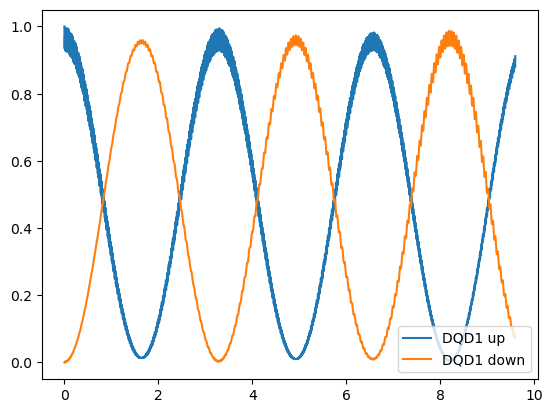

In [18]:
rho = [qt.ket2dm(state) for state in res.states]
rho_DQD1 = [x.ptrace([1,2]) for x in rho]
# rho_DQD2 = [x.ptrace([3,4]) for x in rho]

Rup = U_flop * Rty(-np.pi/2) * tensor(basis(2,0), basis(2,0))
Rdown = U_flop * Rty(-np.pi/2) * tensor(basis(2,1), basis(2,0))

P_rup = Rup * Rup.dag()
P_rdown = Rdown * Rdown.dag()
print(rho_DQD1[0].dims)

display(P_rup)
p_rup1 = np.array([qt.expect(P_rup, st) for st in rho_DQD1])
p_rdown1 = np.array([qt.expect(P_rdown, st) for st in rho_DQD1])
# p_rup2 = np.array([qt.expect(P_rup, st) for st in rho_DQD2])
# print(p_rup)
plt.plot(tlist, p_rup1, label='DQD1 up')
plt.plot(tlist, p_rdown1, label='DQD1 down')
plt.legend(loc=4)
print(tg)


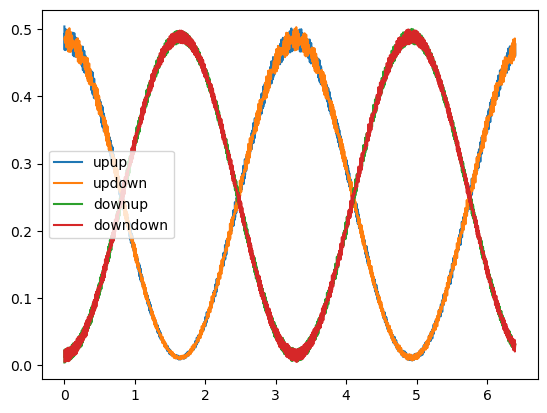

In [ ]:
rho_qubit = [x.ptrace([1,3]) for x in rho]

ket00 = U_flop * Rty(-np.pi/2) * basis([2,2],[0,0])
ket01 = U_flop * Rty(-np.pi/2) * basis([2,2],[0,1])
ket10 = U_flop * Rty(-np.pi/2) * basis([2,2],[1,0])
ket11 = U_flop * Rty(-np.pi/2) * basis([2,2],[1,1])

P00 = ket00 * ket00.dag()
P01 = ket01 * ket01.dag()
P10 = ket10 * ket10.dag()
P11 = ket11 * ket11.dag()

p_00 = np.array([qt.expect(P00, st) for st in rho_qubit])
p_01 = np.array([qt.expect(P01, st) for st in rho_qubit])
p_10 = np.array([qt.expect(P10, st) for st in rho_qubit])
p_11 = np.array([qt.expect(P11, st) for st in rho_qubit])

plt.plot(tlist, p_00, label='upup')
plt.plot(tlist, p_01, label='updown')
plt.plot(tlist, p_10, label='downup')
plt.plot(tlist, p_11, label='downdown')

plt.legend()
